# Summarizes inner loop performance for xgboost models in lag study

Kendra Wyant  
March 24, 2024

### Set Up Environment

In [ ]:

version <- "v2"
algorithms <- "xgboost"
model <- "main"


In [ ]:

options(conflicts.policy = "depends.ok")


In [ ]:

library(tidyverse) |> 
  suppressPackageStartupMessages()

devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/fun_eda.R?raw=true") |> 
  suppressMessages()
theme_set(theme_classic()) 


In [ ]:

source("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true") |> 
  suppressMessages()

path_input <- format_path(str_c("studydata/risk/chtc/lag/"))
path_models <- format_path(str_c("studydata/risk/models/lag/"))


In [ ]:

knitr::opts_chunk$set(attr.output='style="max-height: 500px;"')

options(tibble.width = Inf)
options(tibble.print_max = Inf)


### Read results.csv files

Set up object for results

In [ ]:
results_all <- NULL


Get batch_names

In [ ]:
batch_names <- list.dirs(path_input, full.names = FALSE, recursive = FALSE)
  
if (algorithms == "all") {
  batch_names <- batch_names[str_detect(batch_names, "train") & 
                               str_detect(batch_names, version)]
  if (model == "main") {
    batch_names <- batch_names[!str_detect(batch_names, "baseline")]
  }
} else {
    batch_names <- batch_names[str_detect(batch_names, "train") & 
                               str_detect(batch_names, version) &
                               str_detect(batch_names, algorithms)]
  if (model == "main") {
    batch_names <- batch_names[!str_detect(batch_names, "baseline")]
  }
}  

batch_names


[1] "train_xgboost_1week_0lag_nested_1_x_10_3_x_10_v2_main"  
[2] "train_xgboost_1week_168lag_nested_1_x_10_3_x_10_v2_main"
[3] "train_xgboost_1week_24lag_nested_1_x_10_3_x_10_v2_main" 
[4] "train_xgboost_1week_336lag_nested_1_x_10_3_x_10_v2_main"
[5] "train_xgboost_1week_72lag_nested_1_x_10_3_x_10_v2_main" 

Loop over batch_names to read in files and perform checks

In [ ]:
for (batch_name in batch_names) {
  message("Processing Batch: ", batch_name)
  
  lag <- str_remove(str_split(batch_name, "_")[[1]][4], "lag")
  
  # read in configs
  configs <- read_csv(here::here(path_input, batch_name, "input", "configs.csv"), 
                      show_col_types = FALSE)
  (n_configs <- nrow(configs))
  
  # read in results
  results_batch <- read_csv(here::here(path_input, batch_name, "output", 
                                      "batch_results.csv"), 
                            show_col_types = FALSE) |> 
    mutate(lag = lag)
  (n_results_batch <- nrow(results_batch))
  
  # Check counts of results files
  if (!(n_configs == n_results_batch)) {
    stop(n_configs, " configs != ", n_results_batch, " results files!")
  } else {
    message(n_results_batch, " results files detected.  Correct!")
  }
  
  # Check col count
  if (!(ncol(results_batch) == 18)) {
    stop(ncol(results_batch), " columns != 18")
  } else {
    message(ncol(results_batch), " columns detected.  Correct!\n")
  }

  # Add batch to all metrics
  results_all <- results_all %>% 
    bind_rows(results_batch)
}


Processing Batch: train_xgboost_1week_0lag_nested_1_x_10_3_x_10_v2_main

134400 results files detected.  Correct!

18 columns detected.  Correct!

Processing Batch: train_xgboost_1week_168lag_nested_1_x_10_3_x_10_v2_main

134400 results files detected.  Correct!

...

134400 results files detected.  Correct!

18 columns detected.  Correct!

Processing Batch: train_xgboost_1week_72lag_nested_1_x_10_3_x_10_v2_main

134400 results files detected.  Correct!

18 columns detected.  Correct!

### Wrap up processing of raw metrics

Check for duplicates

In [ ]:
n_results <- nrow(results_all)

results_all <- results_all |> 
  distinct(split_num, outer_split_num, inner_split_num, algorithm, feature_set,
           hp1, hp2, hp3, resample, lag, .keep_all = TRUE)

if (nrow(results_all) != n_results) {
  stop(n_results - nrow(results_all), " duplicates detected")
}


Final checks across all batches

Check 300 performance metrics for all configurations

In [ ]:
results_all |> 
  group_by(algorithm, hp1, hp2, hp3, resample, lag) |> 
  count() |> 
  arrange(n) |> 
  head(n = 50)


# A tibble: 50 × 7
# Groups:   algorithm, hp1, hp2, hp3, resample, lag [50]
   algorithm    hp1   hp2   hp3 resample lag       n
   <chr>      <dbl> <dbl> <dbl> <chr>    <chr> <int>
 1 xgboost   0.0001     1    20 down_1   0       300
 2 xgboost   0.0001     1    20 down_1   168     300
 3 xgboost   0.0001     1    20 down_1   24      300
 4 xgboost   0.0001     1    20 down_1   336     300
 5 xgboost   0.0001     1    20 down_1   72      300
 6 xgboost   0.0001     1    20 down_2   0       300
 7 xgboost   0.0001     1    20 down_2   168     300
 8 xgboost   0.0001     1    20 down_2   24      300
 9 xgboost   0.0001     1    20 down_2   336     300
10 xgboost   0.0001     1    20 down_2   72      300
11 xgboost   0.0001     1    20 up_1     0       300
12 xgboost   0.0001     1    20 up_1     168     300
13 xgboost   0.0001     1    20 up_1     24      300
14 xgboost   0.0001     1    20 up_1     336     300
15 xgboost   0.0001     1    20 up_1     72      300
16 xgboost   0.0001    

### Median metrics across inner folds for model configurations

Inner loop performance of best config. This median performance for each configuration over inner x outer folds (e.g., 300 folds for 1x10 inner and 3x10 outer). It is what we would get (essentially) if we just did simple k-fold but with LOTs of folds

In [ ]:
metrics_avg <- results_all %>% 
  group_by(algorithm, feature_set, hp1, hp2, hp3, resample, lag) %>% 
   summarize(across(c(accuracy, bal_accuracy, roc_auc, sens, spec, ppv, npv),
                    median),
             n_jobs = n(), .groups = "drop") %>% 
  relocate(n_jobs) %>% 
  arrange(desc(roc_auc)) |> 
  ungroup()

best_configs <- metrics_avg |> 
  group_by(lag) |> 
  slice(1) |> 
  arrange(as.numeric(lag)) |> 
  print()


# A tibble: 5 × 15
# Groups:   lag [5]
  n_jobs algorithm feature_set   hp1   hp2   hp3 resample lag   accuracy
   <int> <chr>     <chr>       <dbl> <dbl> <dbl> <chr>    <chr>    <dbl>
1    300 xgboost   all         0.001     4    50 down_1   0        0.820
2    300 xgboost   all         0.01      2    30 down_2   24       0.842
3    300 xgboost   all         0.01      2    50 up_2     72       0.831
4    300 xgboost   all         0.01      2    30 up_2     168      0.836
5    300 xgboost   all         0.01      2    50 down_2   336      0.810
  bal_accuracy roc_auc  sens  spec   ppv   npv
         <dbl>   <dbl> <dbl> <dbl> <dbl> <dbl>
1        0.810   0.889 0.820 0.819 0.594 0.934
2        0.775   0.882 0.681 0.902 0.672 0.894
3        0.765   0.873 0.663 0.888 0.667 0.892
4        0.770   0.870 0.667 0.889 0.651 0.893
5        0.737   0.848 0.624 0.873 0.597 0.879

Performance metric plot across all inner folds

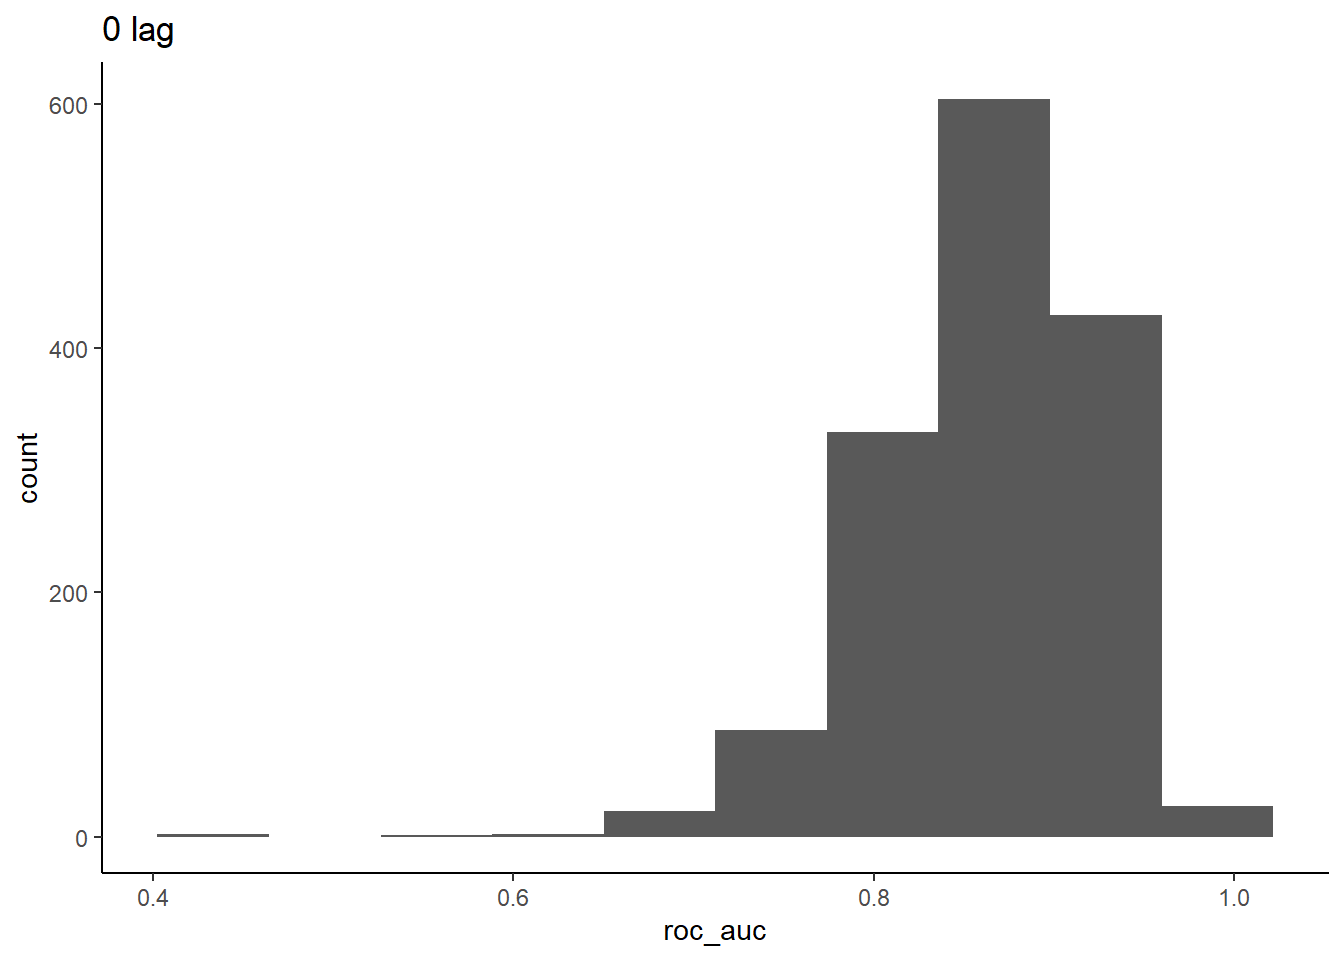

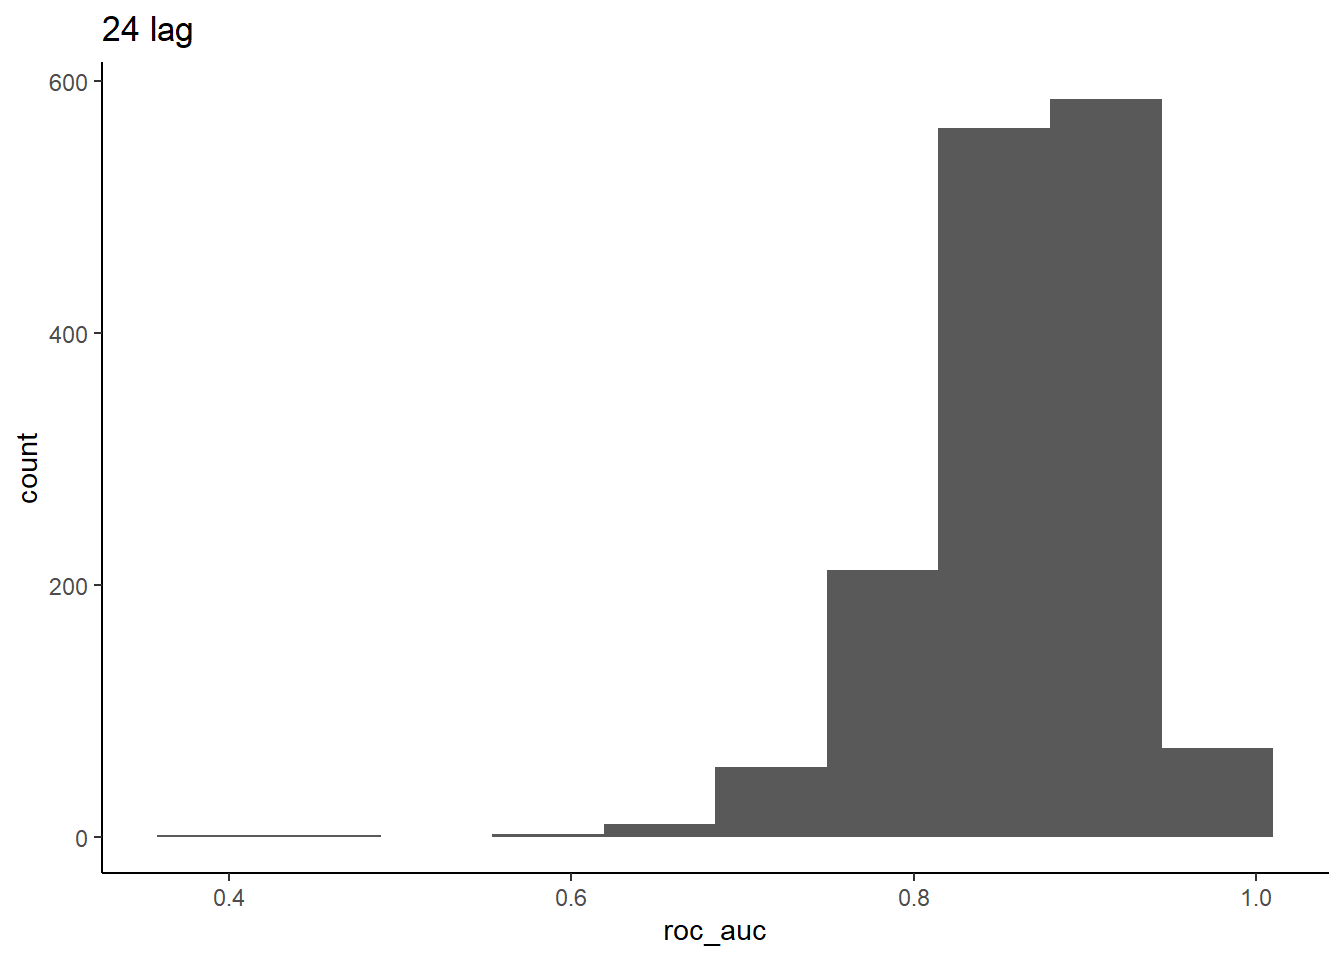

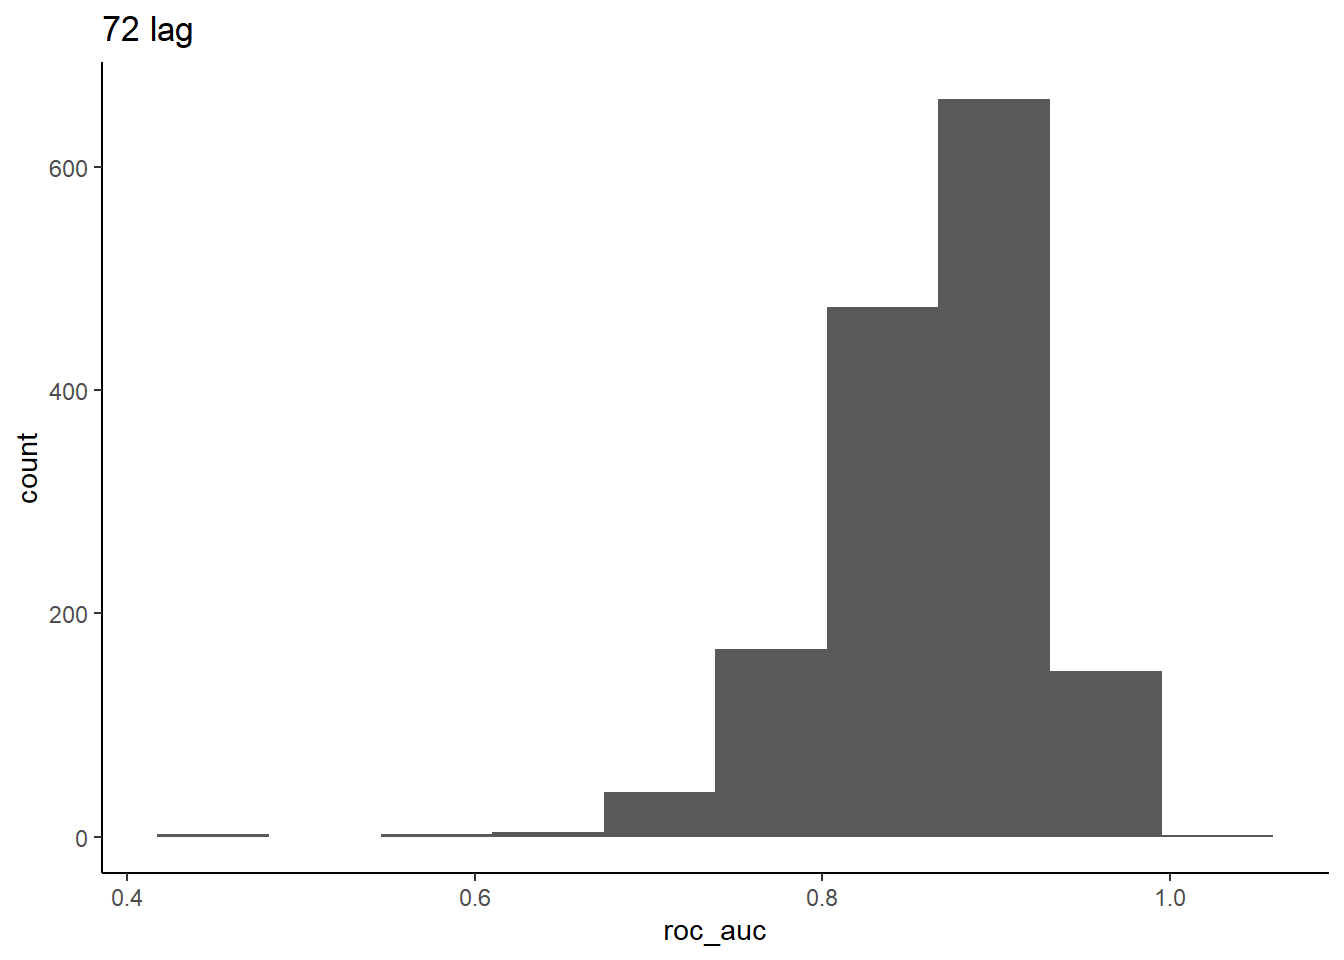

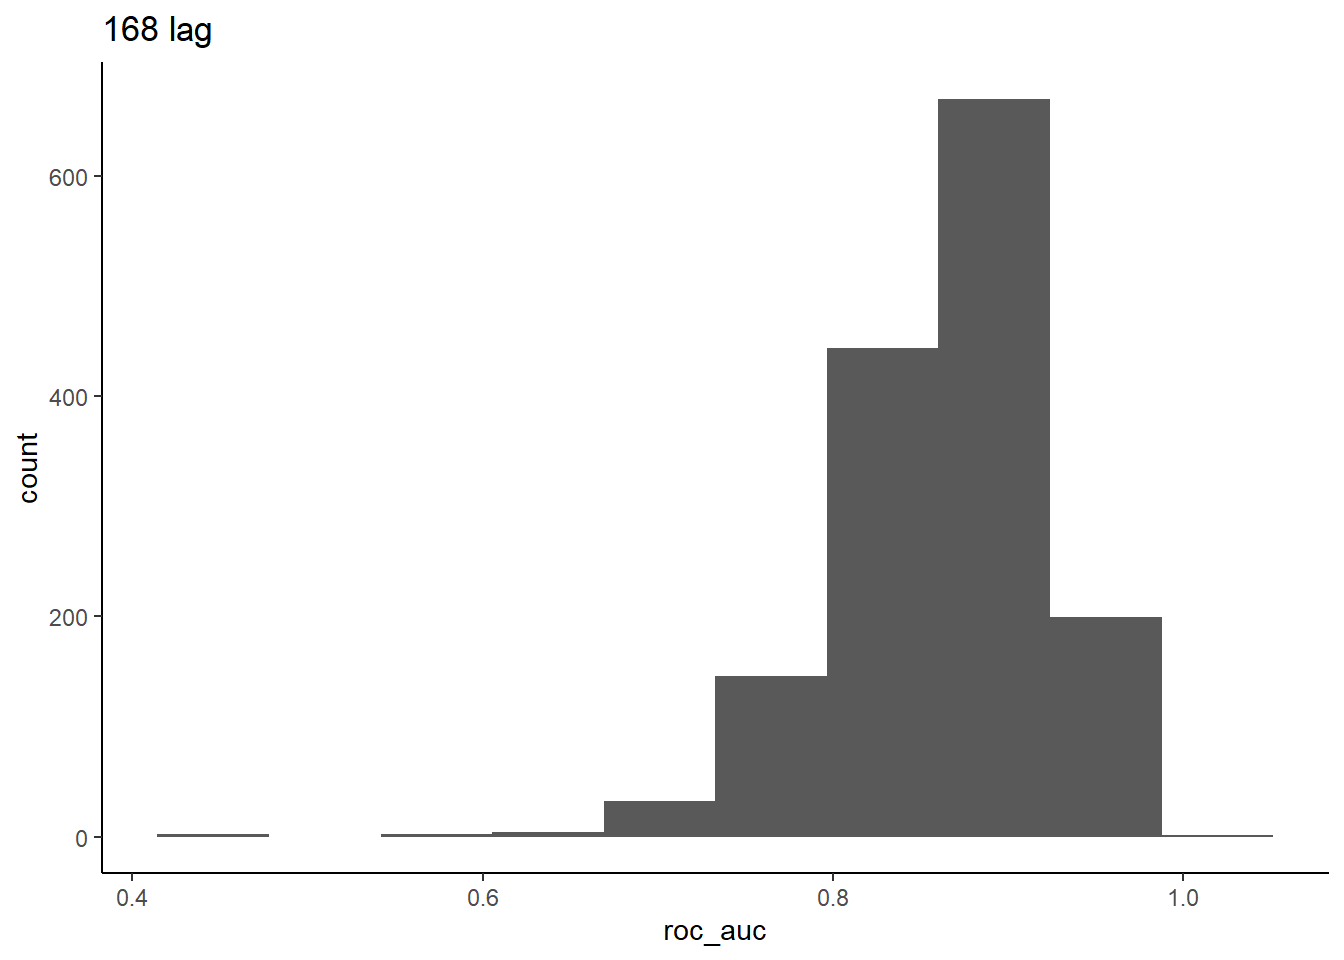

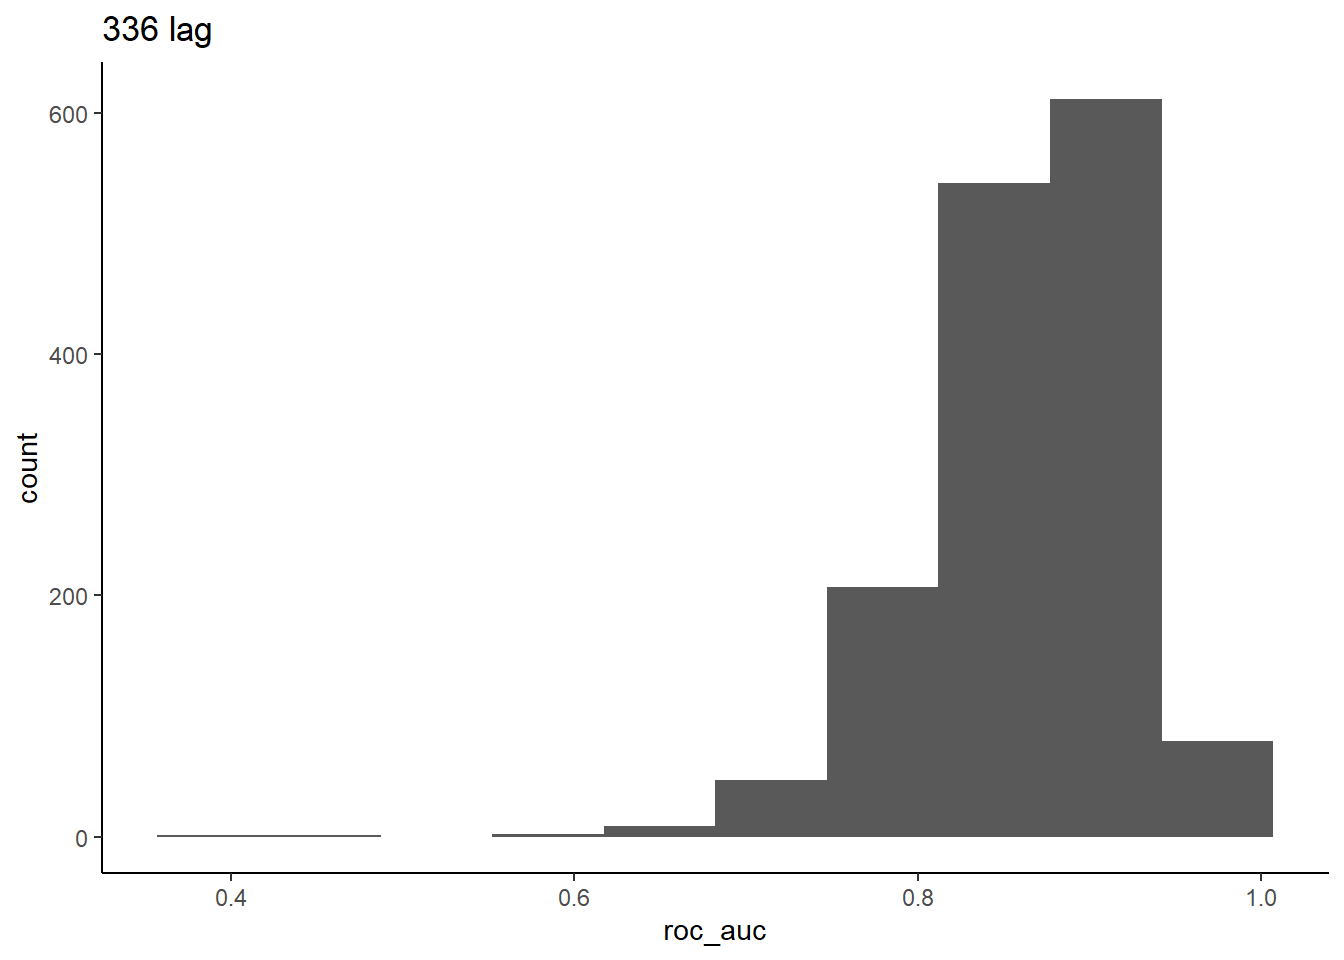

In [ ]:
for (i in 1:nrow(best_configs)) {
  best_config <- best_configs[i,]
  plot <- results_all |> 
    filter(algorithm == best_config$algorithm,
           feature_set == best_config$feature_set,
           hp1 == best_config$hp1,
           hp2 == best_config$hp2,
           hp3 == best_config$hp3,
           resample == best_config$resample) |> 
    ggplot(aes(x = roc_auc)) +
    geom_histogram(bins = 10) +
    labs(title = str_c(best_config$lag, " lag"))
  print(plot)
}
